# Import der notwendigen Bibliotheken

In [5]:
import yfinance as yf
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Datensatz laden

In [3]:
# Apple-Aktie laden
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Schlusskurse auswählen
ts = df["Close"]

print(ts.head())

[*********************100%***********************]  1 of 1 completed

Ticker           AAPL
Date                 
2015-01-02  24.192600
2015-01-05  23.511057
2015-01-06  23.513275
2015-01-07  23.842983
2015-01-08  24.759085


# Aufgabe 3

1. Visualisiere die Daten 
2. Führe eine STL-Zerlegung durch
3. Wie hast du den "period" Parameter festgelegt?
4. Welche Aussagekraft hat die Saisonkomponente? Keine
5. Was sollte vor der Verwendung von STL immer überprüft werden? Wann ist eine STL-Zerlegung sinnvoll? Periodizität in den Daten

# Musterlösung 3.1

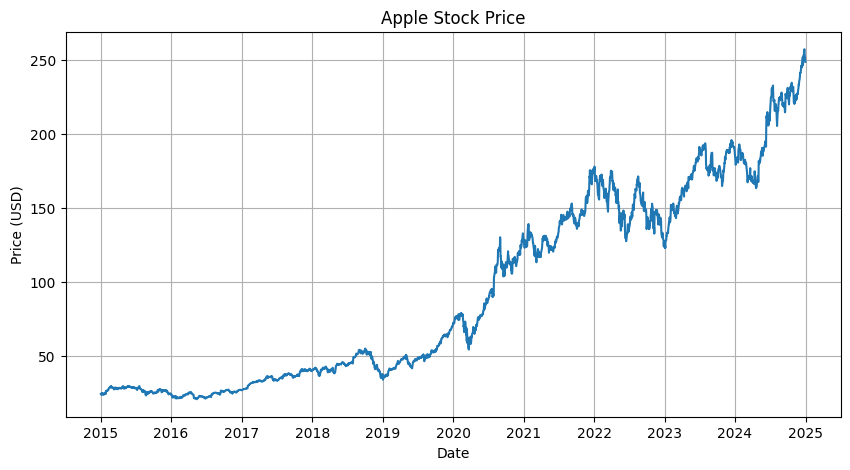

In [6]:
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

# Musterlösung 3.2

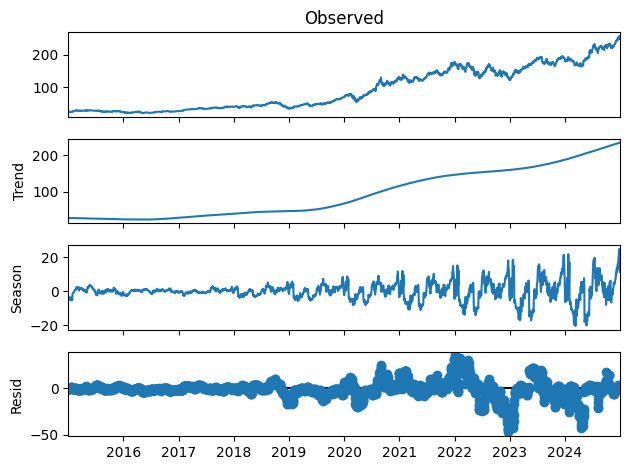

In [7]:
stl = STL(
    ts,
    period=252,      # ca. 252 Handelstage pro Jahr
    seasonal=13,
    robust=True
)

result = stl.fit()

result.plot()
plt.show()

# Musterlösung 3.3

Der Parameter period beschreibt die Länge eines vollständigen saisonalen Zyklus.

Da der Datensatz tägliche Aktienkurse enthält, wurde als Ausgangspunkt die Anzahl der Handelstage pro Jahr gewählt:

period = 252

Dies entspricht ungefähr der Anzahl der Börsenhandelstage eines Jahres.

Wichtig: Die Wahl von period=252 bedeutet nicht, dass tatsächlich eine jährliche Saisonalität vorhanden ist. Sie dient lediglich als Annahme für die Zerlegung.

# Musterlösung 3.4

Die Saisonkomponente besitzt in diesem Beispiel keine sinnvolle wirtschaftliche Aussagekraft.

Begründung:

Aktienkurse weisen in der Regel keine stabile periodische Saisonalität auf.
STL zerlegt jede Zeitreihe unabhängig von ihrer Struktur in Trend, Saison und Residuen.
Die berechnete Saisonkomponente ist daher überwiegend ein Artefakt des Algorithmus und sollte nicht als tatsächliches saisonales Muster interpretiert werden.

# Musterlösung 3.5

Vor der Anwendung von STL sollte geprüft werden, ob die Zeitreihe eine stabile Periodizität bzw. Saisonalität besitzt.

Dies kann beispielsweise erfolgen durch:

visuelle Inspektion der Zeitreihe,
Domänenwissen,
Analyse der Autokorrelation (ACF),
Kenntnisse über den Erhebungsprozess.

Eine STL-Zerlegung ist besonders sinnvoll für Zeitreihen mit regelmäßig wiederkehrenden saisonalen Mustern, z. B.:

monatliche Verkaufszahlen,
Energieverbrauch,
Passagierzahlen,
Wetterdaten.

Für Zeitreihen ohne erkennbare Saisonalität, wie Aktienkurse, liefert STL zwar formal eine Zerlegung, die Saisonkomponente besitzt jedoch in der Regel keine inhaltliche Bedeutung.